In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

print("Libraries imported successfully!")

# Check uploaded files
import os
print(os.listdir('/content'))

Libraries imported successfully!
['.config', 'heart_failure_clinical_records_dataset.csv', 'sample_data']


In [7]:
df = pd.read_csv('/content/heart_failure_clinical_records_dataset.csv')

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [8]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Number of rows: 299
Number of columns: 13

Data Types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Missing Values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


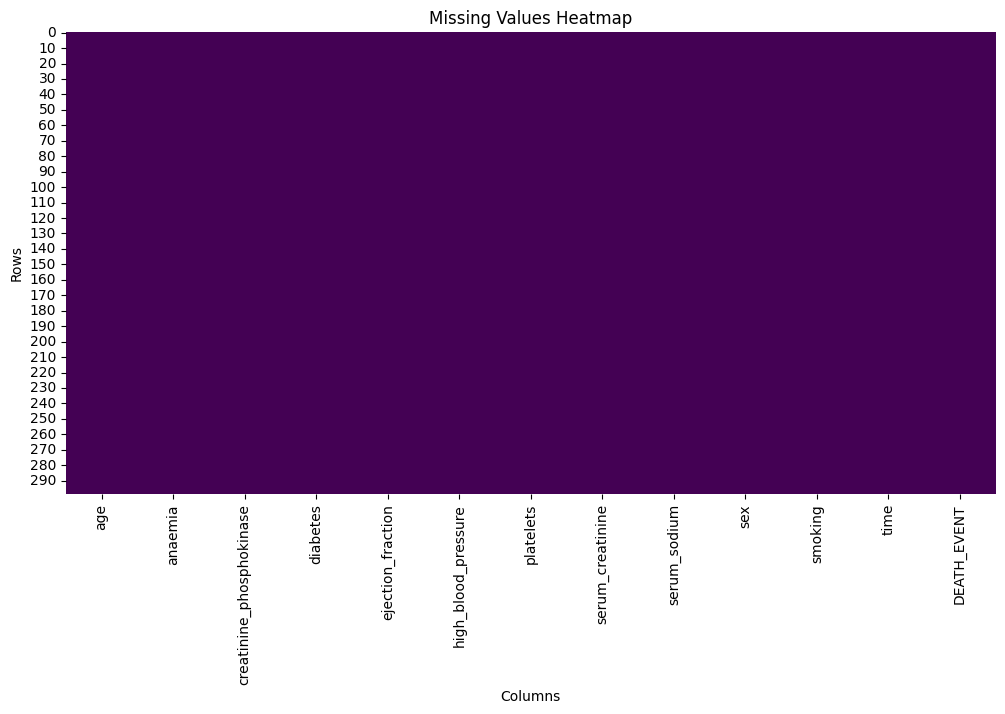

In [9]:
plt.figure(figsize=(12, 6))

sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

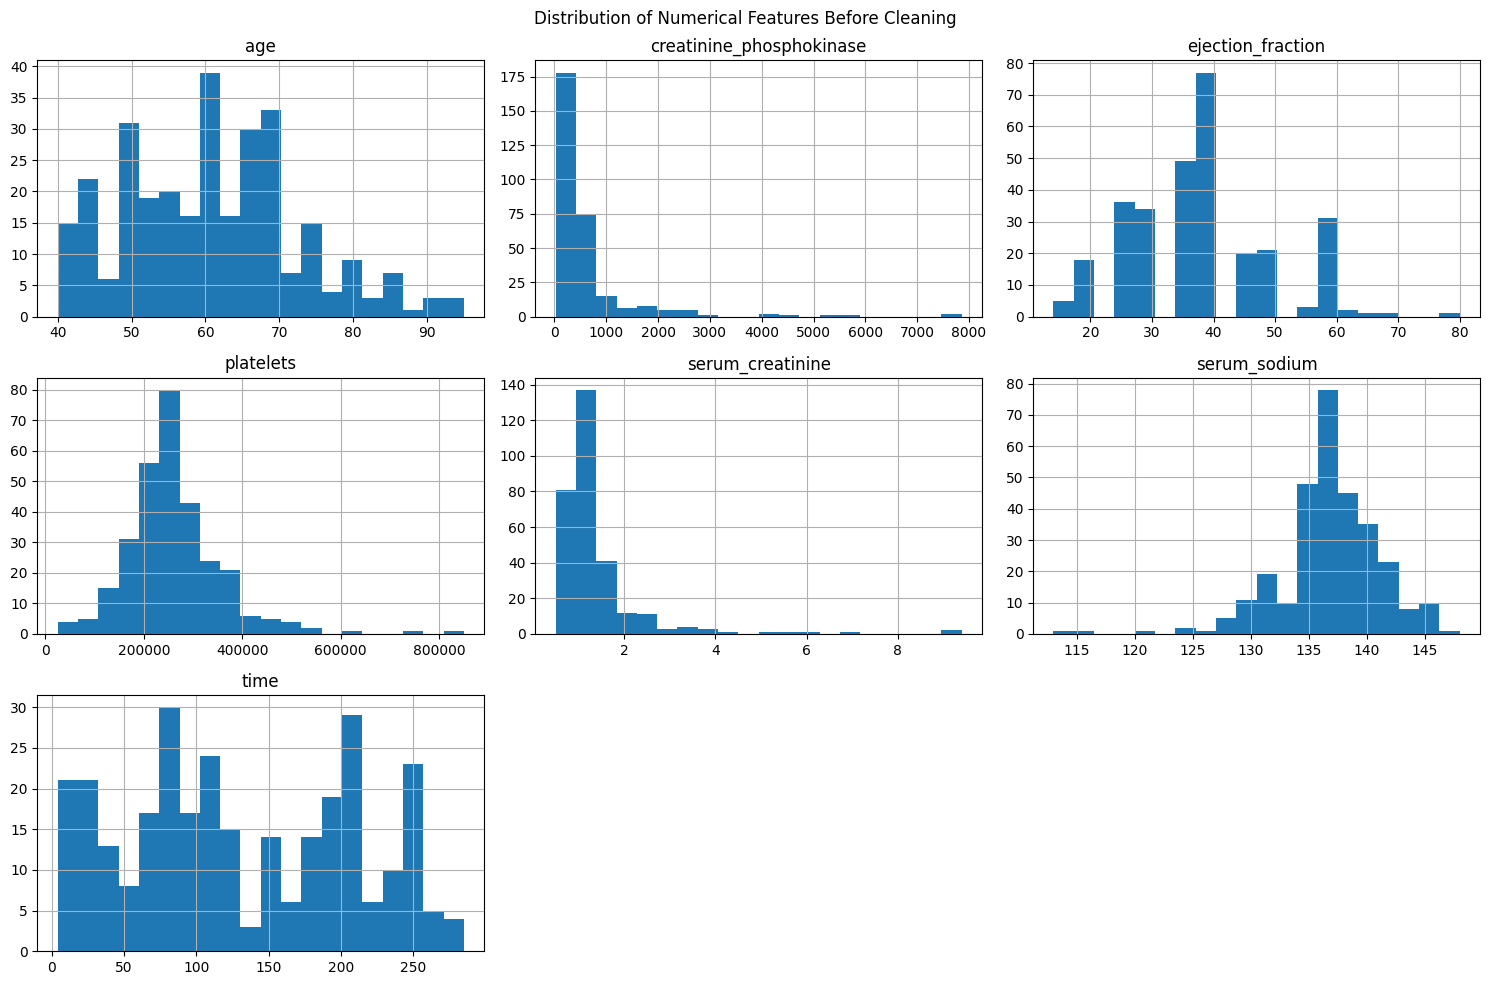

In [10]:
numerical_columns = [
    'age',
    'creatinine_phosphokinase',
    'ejection_fraction',
    'platelets',
    'serum_creatinine',
    'serum_sodium',
    'time'
]

df[numerical_columns].hist(
    figsize=(15, 10),
    bins=20
)

plt.suptitle("Distribution of Numerical Features Before Cleaning")
plt.tight_layout()
plt.show()

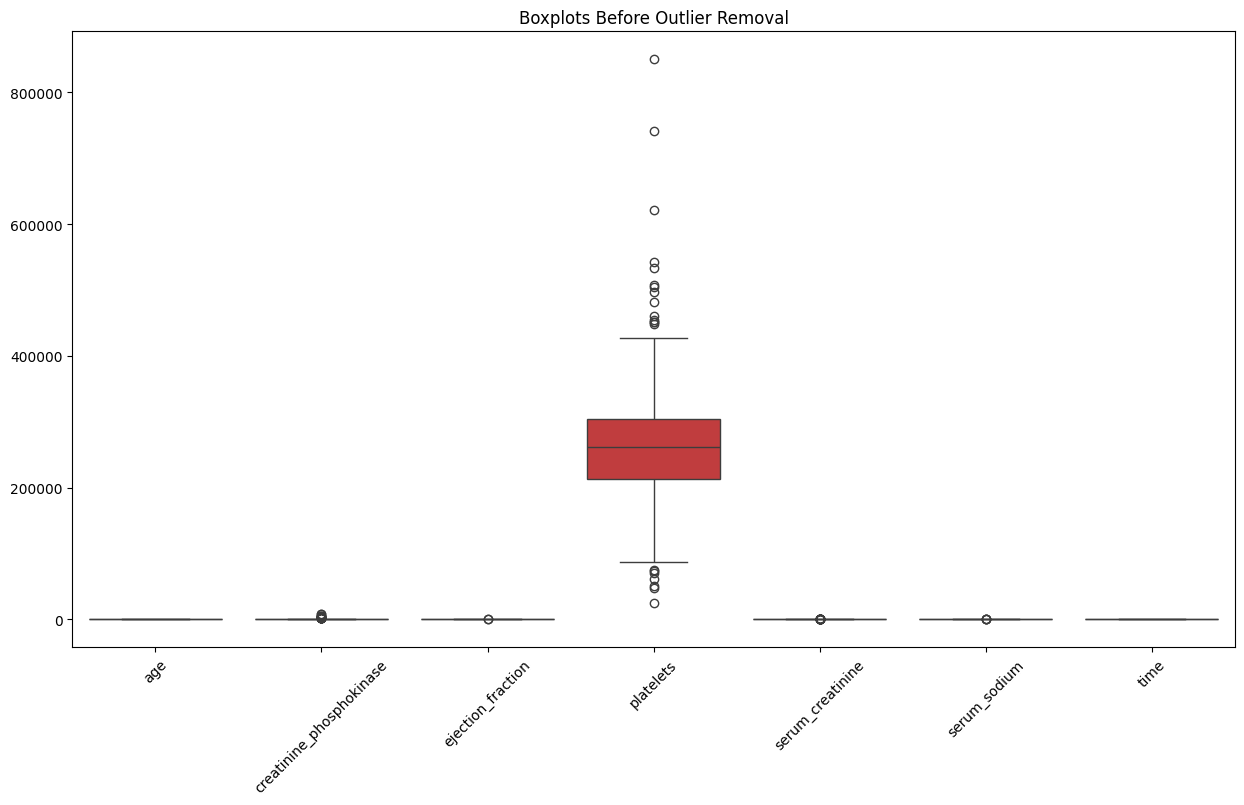

In [11]:
plt.figure(figsize=(15, 8))

sns.boxplot(data=df[numerical_columns])

plt.title("Boxplots Before Outlier Removal")
plt.xticks(rotation=45)
plt.show()

In [12]:
numerical_columns = [
    'age',
    'creatinine_phosphokinase',
    'ejection_fraction',
    'platelets',
    'serum_creatinine',
    'serum_sodium',
    'time'
]

for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

categorical_columns = [
    'anaemia',
    'diabetes',
    'high_blood_pressure',
    'sex',
    'smoking'
]

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])


print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [13]:

print("Negative ages before correction:",
      (df['age'] < 0).sum())

df.loc[df['age'] < 0, 'age'] = np.nan

df['age'] = df['age'].fillna(df['age'].median())

print("Negative ages after correction:",
      (df['age'] < 0).sum())

Negative ages before correction: 0
Negative ages after correction: 0


In [14]:

df_before_outliers = df.copy()

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[
        (df[column] >= lower_bound) &
        (df[column] <= upper_bound)
    ]

print("Rows before outlier removal:", len(df_before_outliers))
print("Rows after outlier removal:", len(df))

Rows before outlier removal: 299
Rows after outlier removal: 224


In [15]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[-np.inf, 40, 60, np.inf],
    labels=['<40', '40-60', '>60']
)

print(df[['age', 'age_group']].head(10))

     age age_group
0   75.0       >60
2   65.0       >60
3   50.0     40-60
5   90.0       >60
6   75.0       >60
8   65.0       >60
11  62.0       >60
12  45.0     40-60
13  50.0     40-60
14  49.0     40-60


In [16]:

df['risk_score_raw'] = (
    df['ejection_fraction'] *
    df['serum_creatinine']
)

scaler = MinMaxScaler()

df['risk_score'] = scaler.fit_transform(
    df[['risk_score_raw']]
)

print(df[
    ['ejection_fraction',
     'serum_creatinine',
     'risk_score_raw',
     'risk_score']
].head())

   ejection_fraction  serum_creatinine  risk_score_raw  risk_score
0                 20               1.9            38.0    0.310545
2                 20               1.3            26.0    0.171495
3                 20               1.9            38.0    0.310545
5                 40               2.1            84.0    0.843569
6                 15               1.2            18.0    0.078795


In [17]:
df = pd.get_dummies(
    df,
    columns=['age_group'],
    drop_first=True,
    dtype=int
)

print("Dataset after encoding:")
print(df.head())

print("\nColumns:")
print(df.columns.tolist())

Dataset after encoding:
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
5  90.0        1                        47         0                 40   
6  75.0        1                       246         0                 15   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1   265000.0               1.9           130    1   
2                    0   162000.0               1.3           129    1   
3                    0   210000.0               1.9           137    1   
5                    1   204000.0               2.1           132    1   
6                    0   127000.0               1.2           137    1   

   smoking  time  DEATH_EVENT  risk_score_raw  risk_score  age_group_40-60  \
0 

In [18]:
scaler = MinMaxScaler()

columns_to_scale = [
    'age',
    'creatinine_phosphokinase',
    'ejection_fraction',
    'platelets',
    'serum_creatinine',
    'serum_sodium',
    'time',
    'risk_score_raw'
]

df[columns_to_scale] = scaler.fit_transform(
    df[columns_to_scale]
)

df.rename(
    columns={'risk_score_raw': 'risk_score_normalized'},
    inplace=True
)

print(df.head())

        age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  0.636364        0                  0.470990         0           0.117647   
2  0.454545        0                  0.098976         0           0.117647   
3  0.181818        1                  0.069113         0           0.117647   
5  0.909091        1                  0.014505         0           0.509804   
6  0.636364        1                  0.184300         0           0.019608   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1   0.468852          0.866667      0.217391    1   
2                    0   0.131148          0.466667      0.173913    1   
3                    0   0.288525          0.866667      0.521739    1   
5                    1   0.268852          1.000000      0.304348    1   
6                    0   0.016393          0.400000      0.521739    1   

   smoking      time  DEATH_EVENT  risk_score_normalized  risk_score  \
0       

In [19]:
print("SUMMARY STATISTICS BEFORE CLEANING")

print(
    df_before_outliers[numerical_columns]
    .agg(['mean', 'median', 'std'])
)

SUMMARY STATISTICS BEFORE CLEANING
              age  creatinine_phosphokinase  ejection_fraction      platelets  \
mean    60.833893                581.839465          38.083612  263358.029264   
median  60.000000                250.000000          38.000000  262000.000000   
std     11.894809                970.287881          11.834841   97804.236869   

        serum_creatinine  serum_sodium        time  
mean             1.39388    136.625418  130.260870  
median           1.10000    137.000000  115.000000  
std              1.03451      4.412477   77.614208  


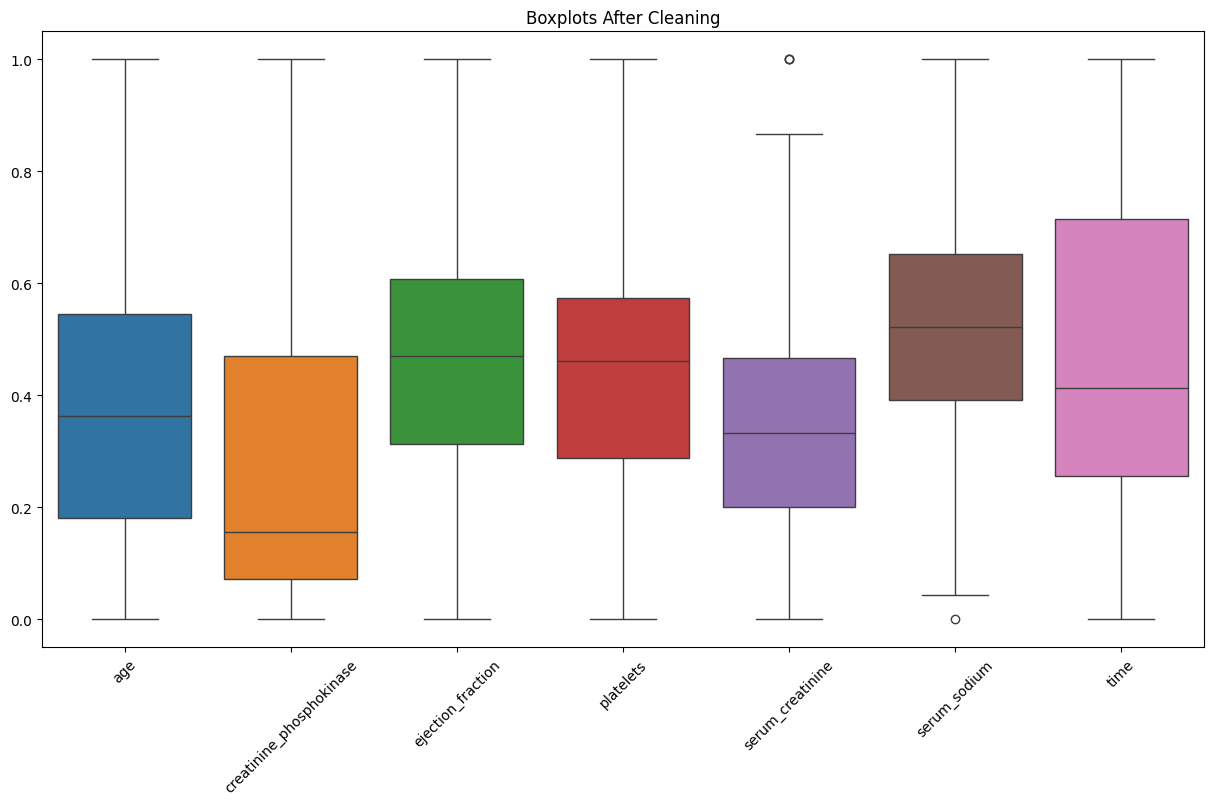

In [20]:
plt.figure(figsize=(15, 8))

sns.boxplot(data=df[numerical_columns])

plt.title("Boxplots After Cleaning")
plt.xticks(rotation=45)
plt.show()

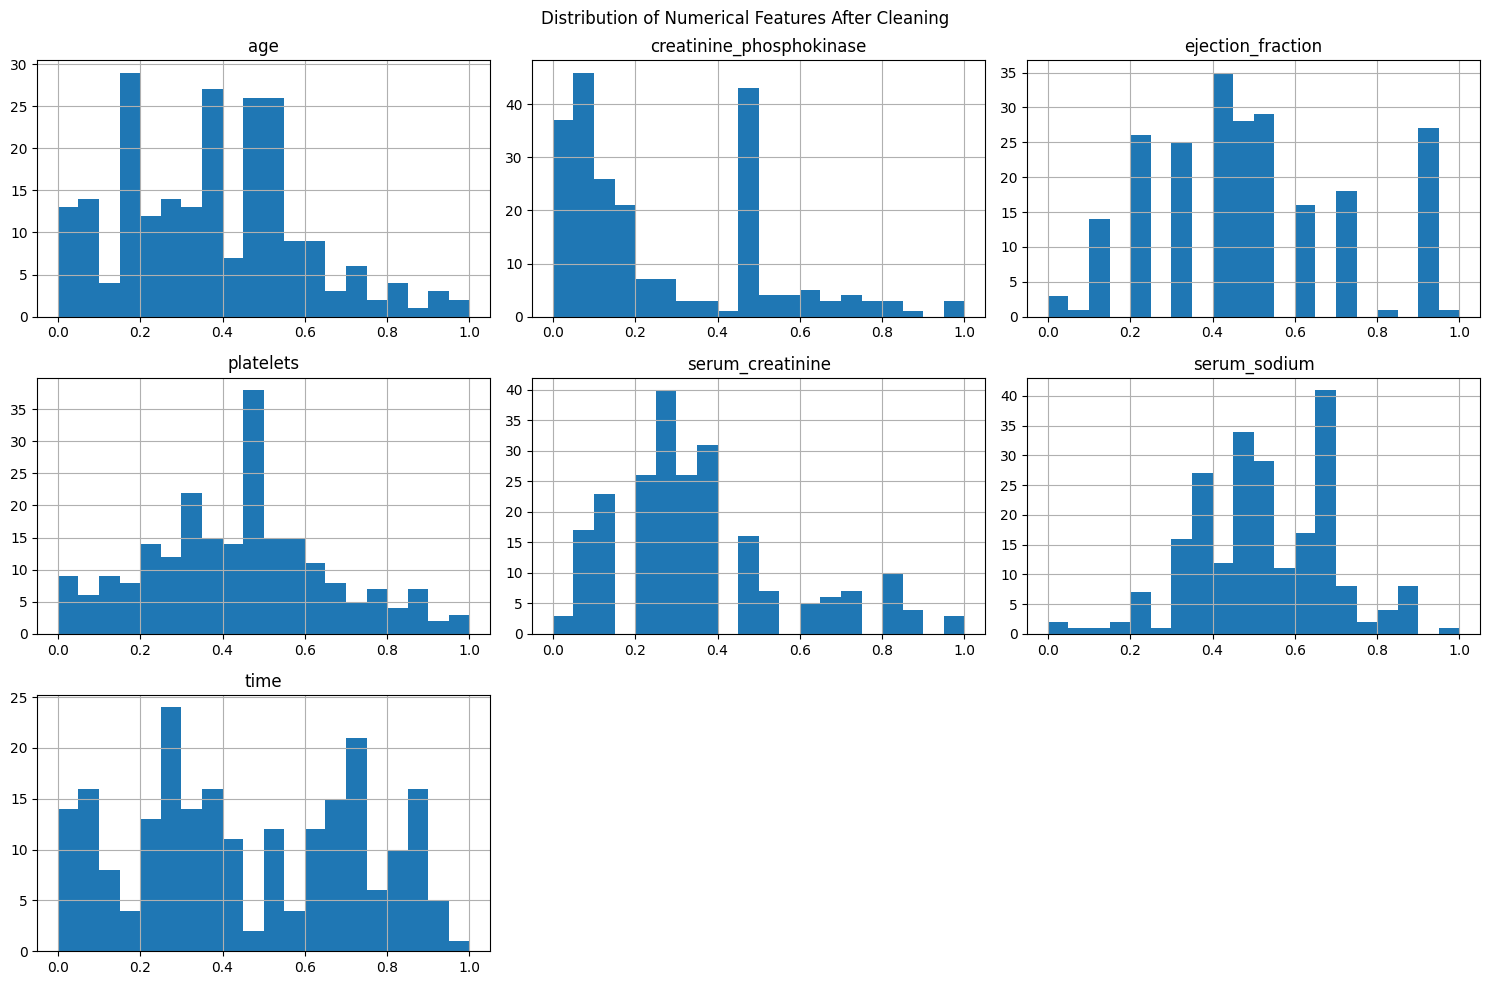

In [21]:
df[numerical_columns].hist(
    figsize=(15, 10),
    bins=20
)

plt.suptitle("Distribution of Numerical Features After Cleaning")
plt.tight_layout()
plt.show()

In [22]:
print("Missing values in cleaned dataset:")
print(df.isnull().sum())

print("\nTotal missing values:",
      df.isnull().sum().sum())

Missing values in cleaned dataset:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
risk_score_normalized       0
risk_score                  0
age_group_40-60             0
age_group_>60               0
dtype: int64

Total missing values: 0


In [23]:
print("Final dataset shape:", df.shape)

df.head()

Final dataset shape: (224, 17)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,risk_score_normalized,risk_score,age_group_40-60,age_group_>60
0,0.636364,0,0.470990,0,0.117647,1,0.468852,0.866667,0.217391,1,0,0.000000,1,0.310545,0.310545,0,1
2,0.454545,0,0.098976,0,0.117647,0,0.131148,0.466667,0.173913,1,1,0.010676,1,0.171495,0.171495,0,1
3,0.181818,1,0.069113,0,0.117647,0,0.288525,0.866667,0.521739,1,0,0.010676,1,0.310545,0.310545,1,0
5,0.909091,1,0.014505,0,0.509804,1,0.268852,1.000000,0.304348,1,1,0.014235,1,0.843569,0.843569,0,1
6,0.636364,1,0.184300,0,0.019608,0,0.016393,0.400000,0.521739,1,0,0.021352,1,0.078795,0.078795,0,1
